In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [3]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [5]:
from zipfile import ZipFile

with ZipFile("/content/archive (12).zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [6]:
import os

print(os.listdir("/content"))

['.config', 'archive (12).zip', 'mnist_png', 'sample_data']


In [7]:
for root, dirs, files in os.walk("/content"):
    print(root)
    if len(files) > 0:
        print(files[:5])
    print("-"*40)

/content
['archive (12).zip']
----------------------------------------
/content/.config
['hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'active_config', '.last_update_check.json', 'config_sentinel', 'default_configs.db']
----------------------------------------
/content/.config/configurations
['config_default']
----------------------------------------
/content/.config/logs
----------------------------------------
/content/.config/logs/2026.06.04
['13.32.02.654775.log', '13.32.18.735754.log', '13.31.42.499627.log', '13.32.39.344962.log', '13.32.21.210570.log']
----------------------------------------
/content/mnist_png
----------------------------------------
/content/mnist_png/testing
----------------------------------------
/content/mnist_png/testing/6
['5898.png', '5199.png', '7576.png', '5136.png', '2267.png']
----------------------------------------
/content/mnist_png/testing/7
['5485.png', '702.png', '1175.png', '1505.png', '4690.png']
--------------------------

In [10]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current Working Directory:
/content

Files:
['.config', 'archive (12).zip', 'mnist_png', 'sample_data']


In [11]:
from zipfile import ZipFile

with ZipFile("archive (12).zip", "r") as zip_ref:
    zip_ref.extractall("mnist_data")

In [12]:
import os

for root, dirs, files in os.walk("mnist_data"):
    print(root)

mnist_data
mnist_data/mnist_png
mnist_data/mnist_png/testing
mnist_data/mnist_png/testing/6
mnist_data/mnist_png/testing/7
mnist_data/mnist_png/testing/2
mnist_data/mnist_png/testing/1
mnist_data/mnist_png/testing/5
mnist_data/mnist_png/testing/8
mnist_data/mnist_png/testing/4
mnist_data/mnist_png/testing/0
mnist_data/mnist_png/testing/9
mnist_data/mnist_png/testing/3
mnist_data/mnist_png/training
mnist_data/mnist_png/training/6
mnist_data/mnist_png/training/7
mnist_data/mnist_png/training/2
mnist_data/mnist_png/training/1
mnist_data/mnist_png/training/5
mnist_data/mnist_png/training/8
mnist_data/mnist_png/training/4
mnist_data/mnist_png/training/0
mnist_data/mnist_png/training/9
mnist_data/mnist_png/training/3


In [13]:
train_dataset = datasets.ImageFolder(
    "mnist_data/mnist_png/training",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    "mnist_data/mnist_png/testing",
    transform=transform
)

In [14]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

NameError: name 'train_loader' is not defined

In [15]:
print(train_dataset)

Dataset ImageFolder
    Number of datapoints: 60000
    Root location: mnist_data/mnist_png/training
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )


In [16]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [17]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 1, 28, 28])
torch.Size([128])


In [18]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [19]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 1, 28, 28])
torch.Size([128])


In [20]:
print(train_dataset)
print(test_dataset)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print(train_loader)

Dataset ImageFolder
    Number of datapoints: 60000
    Root location: mnist_data/mnist_png/training
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )
Dataset ImageFolder
    Number of datapoints: 10000
    Root location: mnist_data/mnist_png/testing
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )


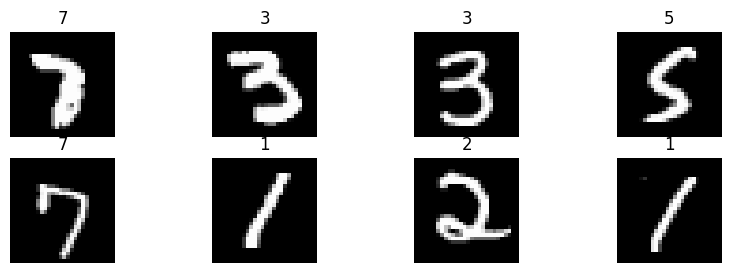

In [21]:
images, labels = next(iter(train_loader))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(labels[i].item())
    plt.axis("off")

plt.show()

In [22]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

In [23]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

In [24]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


In [26]:
import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [27]:
num_epochs = 10

train_losses = []

In [28]:
for epoch in range(num_epochs):

    running_loss = 0.0

    model.train()

    for images, _ in train_loader:

        images = images.to(device)

        noisy_images = add_noise(images)

        noisy_images = noisy_images.to(device)

        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/10] Loss: 0.1061
Epoch [2/10] Loss: 0.0223
Epoch [3/10] Loss: 0.0193
Epoch [4/10] Loss: 0.0182
Epoch [5/10] Loss: 0.0176
Epoch [6/10] Loss: 0.0172
Epoch [7/10] Loss: 0.0168
Epoch [8/10] Loss: 0.0165
Epoch [9/10] Loss: 0.0163
Epoch [10/10] Loss: 0.0161


In [29]:
model.eval()

images, _ = next(iter(test_loader))

images = images.to(device)

noisy_images = add_noise(images)

with torch.no_grad():
    outputs = model(noisy_images)

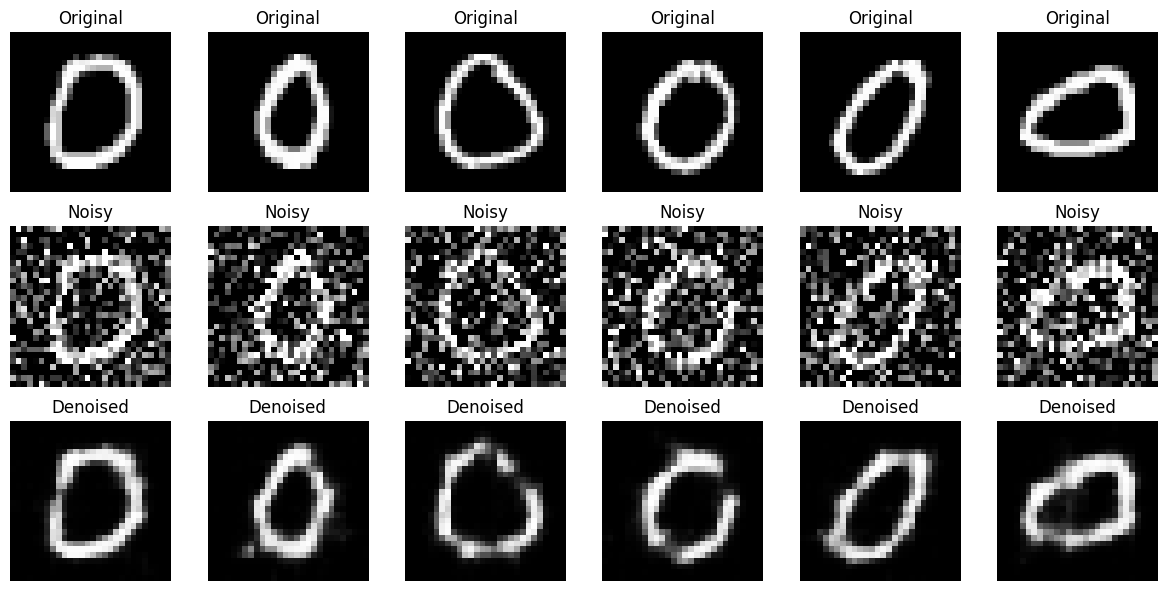

In [30]:
images = images.cpu()
noisy_images = noisy_images.cpu()
outputs = outputs.cpu()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(6):

    # Original
    plt.subplot(3,6,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3,6,i+7)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3,6,i+13)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
torch.save(model.state_dict(), "mnist_autoencoder.pth")